# BIAS DISTRIBUTION ANALYSIS

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pandas as pd

In [94]:
df = pd.read_csv("./data/r2.csv",keep_default_na=False)
df["REPETITION"] = df["REPETITION"].astype(np.uint8)
df["QUESTION_NUM"] = df["QUESTION_NUM"].astype(np.uint8)
#get video number Robusto2_XXX and convert to int8
def get_video_num(video_str):
    try:
        return int(video_str.split("_")[1])
    except (IndexError, ValueError):
        return np.nan
df["BLOCK"] = df["BLOCK"].astype(np.uint8)
df["VIDEO"] = df["VIDEO"].astype("category")
df["AGENT"] = df["AGENT"].astype("category")

#check for non strings in the ANSWER column
non_string_answers = df[~df['ANSWER'].apply(lambda x: isinstance(x, str))]
print("Non-string answers:")
print(non_string_answers)

df.info()

Non-string answers:
Empty DataFrame
Columns: [AGENT, VIDEO, BLOCK, QUESTION_NUM, REPETITION, ANSWER]
Index: []
<class 'pandas.DataFrame'>
RangeIndex: 86000 entries, 0 to 85999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   AGENT         86000 non-null  category
 1   VIDEO         86000 non-null  category
 2   BLOCK         86000 non-null  uint8   
 3   QUESTION_NUM  86000 non-null  uint8   
 4   REPETITION    86000 non-null  uint8   
 5   ANSWER        86000 non-null  str     
dtypes: category(2), str(1), uint8(3)
memory usage: 9.0 MB


In [95]:
def to_numeric(answer):
    try:
        return float(answer)
    except ValueError:
        return np.nan
#select the rows where BKLOCK is 2
df_b2 = df[df["BLOCK"] == 2]
df_b2["ANSWER"] = df_b2["ANSWER"].apply(to_numeric)
#now  we have to compute the consensuis for each question and video from the human answers we must have two consensues for lima and nyc
human_mask = df_b2["AGENT"].apply(lambda x: "human" in x.lower())
df_humans = df_b2[human_mask]
df_vlms = df_b2[~human_mask]
#segregate in two groups nyc or lima

df_humans["REGION"] = df_humans["AGENT"].apply(lambda x: "NYC" if "nyc" in x.lower() else "LIMA")
#group in base of video question and region and compute the consensus as the mean of the answers
agg_df = (
    df_humans
    .groupby(
        ["VIDEO", "QUESTION_NUM", "REGION"],
        as_index=False
    )["ANSWER"]
    .mean()
)
human_consensus = agg_df
human_consensus

,VIDEO,QUESTION_NUM,REGION,ANSWER
0,Robusto2_113,6,LIMA,4.5
1,Robusto2_113,6,NYC,2.8
2,Robusto2_113,7,LIMA,7.7
3,Robusto2_113,7,NYC,7.6
4,Robusto2_113,8,LIMA,3.2
...,...,...,...,...
195,Robusto2_82,8,NYC,4.4
196,Robusto2_82,9,LIMA,6.2
197,Robusto2_82,9,NYC,8.8
198,Robusto2_82,10,LIMA,7.9


In [96]:
#now compute the bias of all the vlms compared to the human cosnesns of the same video and question join

r = pd.merge(df_vlms, human_consensus, on=["VIDEO", "QUESTION_NUM"], how="inner", suffixes=("_VLM", "_HUMAN"))
r["BIAS"] = r["ANSWER_VLM"] - r["ANSWER_HUMAN"]
r["AGENT"] = r["AGENT"].astype("str")
r

,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER_VLM,REGION,ANSWER_HUMAN,BIAS
0,Cosmos-Reason2-8B,Robusto2_18,2,6,1,8.0,LIMA,6.3,1.7
1,Cosmos-Reason2-8B,Robusto2_18,2,6,1,8.0,NYC,4.0,4.0
2,Cosmos-Reason2-8B,Robusto2_18,2,6,2,8.0,LIMA,6.3,1.7
3,Cosmos-Reason2-8B,Robusto2_18,2,6,2,8.0,NYC,4.0,4.0
4,Cosmos-Reason2-8B,Robusto2_18,2,6,3,9.0,LIMA,6.3,2.7
...,...,...,...,...,...,...,...,...,...
39995,VideoLLaMA3-7B,Robusto2_195,2,10,18,7.0,NYC,9.0,-2.0
39996,VideoLLaMA3-7B,Robusto2_195,2,10,19,7.0,LIMA,8.7,-1.7
39997,VideoLLaMA3-7B,Robusto2_195,2,10,19,7.0,NYC,9.0,-2.0
39998,VideoLLaMA3-7B,Robusto2_195,2,10,20,6.0,LIMA,8.7,-2.7


Text(0.5, 1.0, 'Bias Distribution of VLMs Compared to Human Consensus')

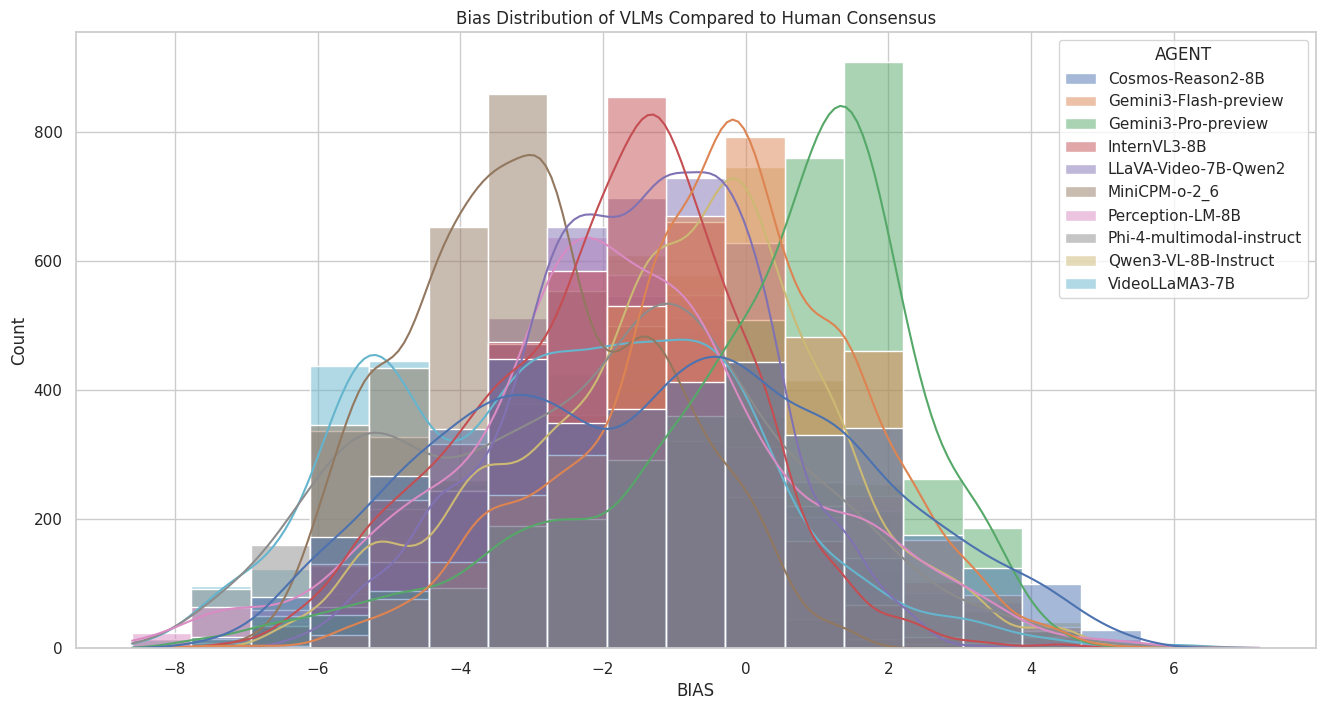

In [97]:
import seaborn as sns
#now plot histogram of the bias for each vlm
plt.figure(figsize=(16, 8))

sns.histplot(data=r, x="BIAS",hue="AGENT", kde=True, bins=19)
plt.title("Bias Distribution of VLMs Compared to Human Consensus")


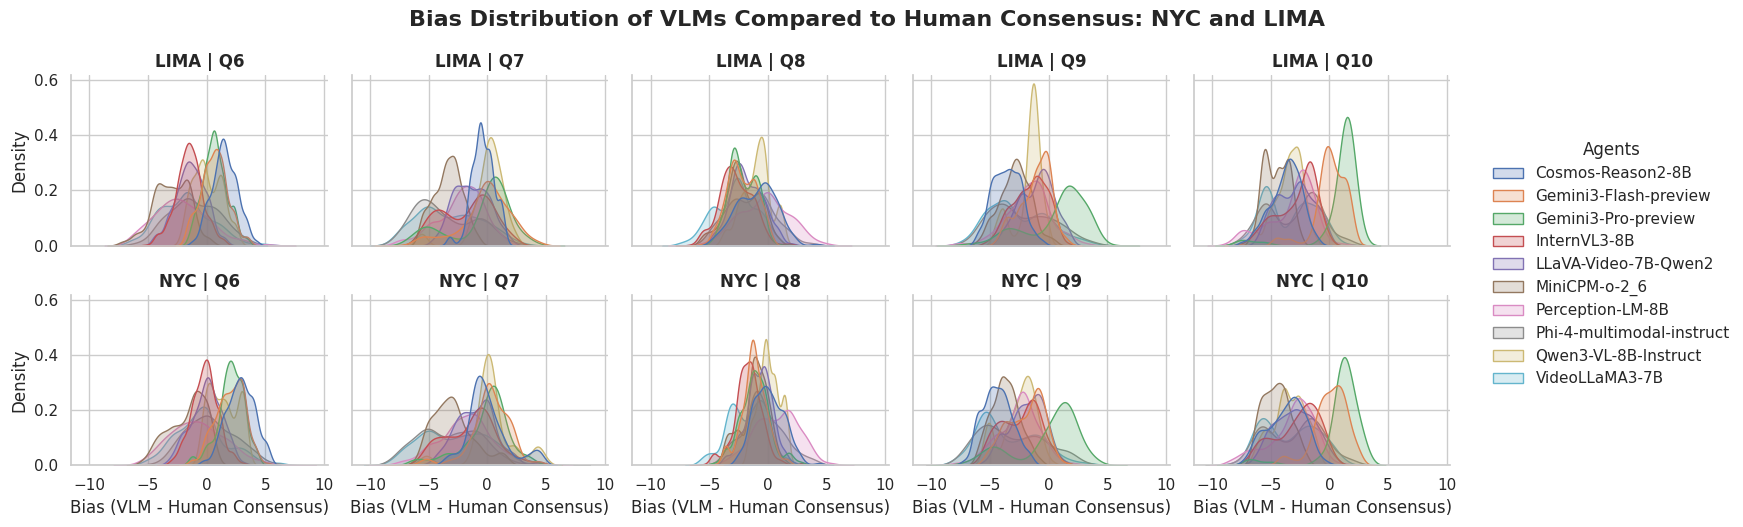

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Usamos displot con kind="kde"
# 'col' crea las 5 columnas (preguntas)
# 'row' crea las 2 filas (regiones: LIMA/NYC)
g = sns.displot(
    data=r, 
    x="BIAS", 
    hue="AGENT", 
    row="REGION", 
    col="QUESTION_NUM", 
    kind="kde", 
    fill=True,
    height=2.5,    # Altura de cada subplot
    aspect=1.2,  # Proporción ancho/alto
    common_norm=False
)

# 2. Personalización rápida con el objeto FacetGrid (g)
g.set_titles(row_template="{row_name}", col_template="Q{col_name}", fontweight='bold')
g.set_axis_labels("Bias (VLM - Human Consensus)", "Density")


# 3. Título global (Seaborn deja espacio automáticamente)
g.figure.suptitle(
    "Bias Distribution of VLMs Compared to Human Consensus: NYC and LIMA",
    y=1.05, 
    fontsize=16, 
    fontweight='bold'
)
# La leyenda se crea GLOBAL y afuera por defecto. 
# Si quieres moverla o editarla:
g._legend.set_title("Agents")

plt.savefig("bias_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

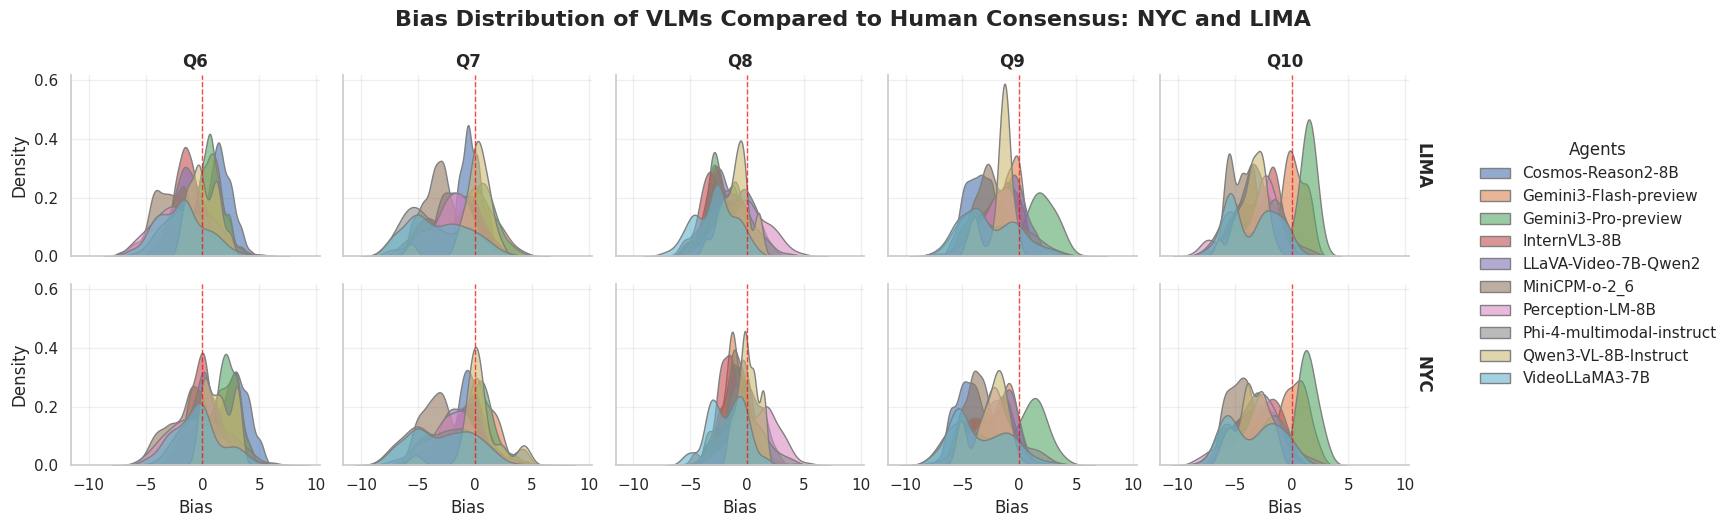

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.color_palette("deep")
# 1. Configuración del Grid
# margin_titles=True es lo que pone "LIMA/NYC" a la derecha limpiamente
g = sns.FacetGrid(r, row="REGION", col="QUESTION_NUM", hue="AGENT", 
                  height=2.5, aspect=1.2, margin_titles=True, sharey=True)

# 2. El truco de la escala: common_norm=False
# Esto asegura que la densidad (eje Y) sea comparable y no dependa del tamaño de la muestra
g.map_dataframe(sns.kdeplot, x="BIAS", fill=True, common_norm=False,edgecolor="gray", alpha=0.6)

# 3. Estética de Paper
g.set_titles(row_template="{row_name}", col_template="Q{col_name}", fontweight='bold')
g.set_axis_labels("Bias", "Density")

# 4. Título y Leyenda
g.figure.suptitle("Bias Distribution of VLMs Compared to Human Consensus: NYC and LIMA", 
                 fontsize=16, fontweight='bold', y=1.05)
g.add_legend(title="Agents")


#add a vertical line at x=0 in all the subplots
for ax in g.axes.flat:
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1,
        color="red",
        alpha=0.7
    )
    ax.grid(True, alpha=0.3)


# Guardar con alta resolución para la publicación
plt.savefig("bias_distribution_final.png", dpi=150, bbox_inches='tight')
plt.show()

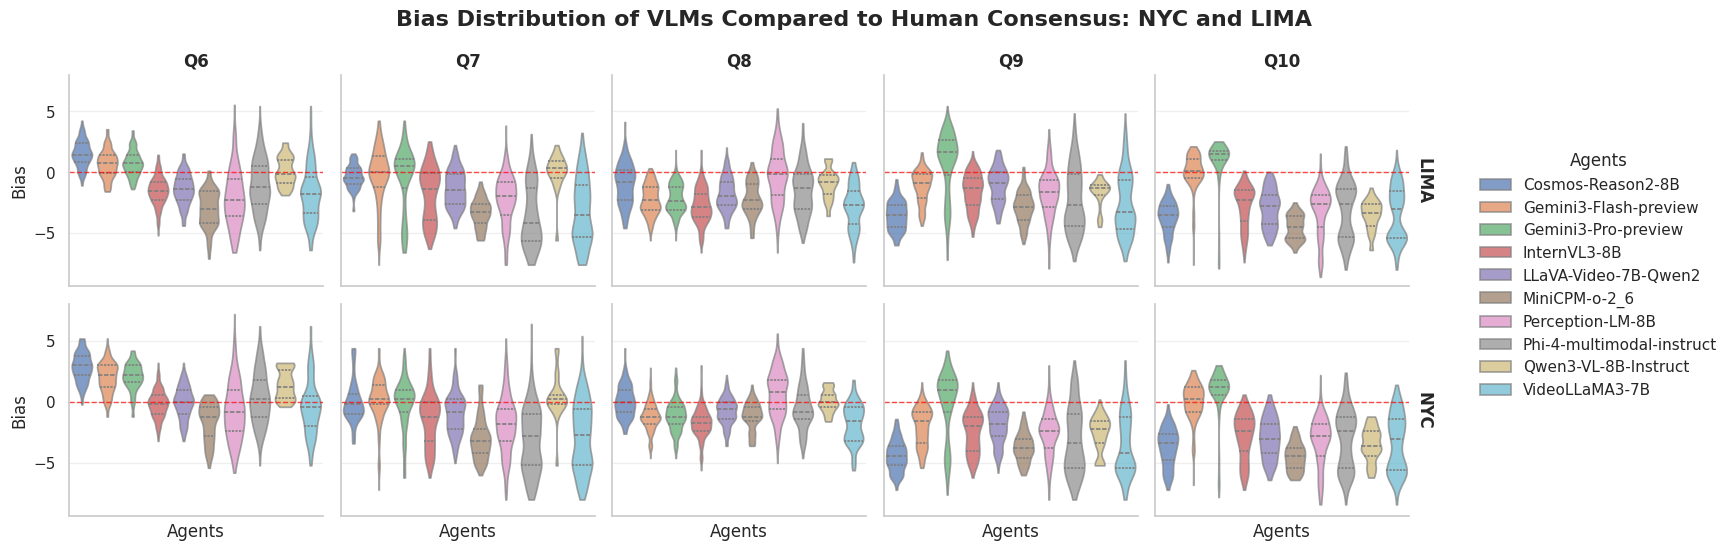

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.color_palette("deep")

g = sns.FacetGrid(
    r,
    row="REGION",
    col="QUESTION_NUM",
    hue="AGENT",
    height=2.5,
    aspect=1.2,
    margin_titles=True,
    sharey=True,
    sharex=True
)

g.map_dataframe(
    sns.violinplot,
    x="AGENT",
    y="BIAS",
    inner="quart",
    cut=0,
    dodge=False,
    legend=False,          # evitamos leyenda repetida
    edgecolor="gray",
    saturation=1,
    alpha=0.7
)
for ax in g.axes.flat:
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(bottom=False)
    ax.grid(True, alpha=0.3)


plt.tight_layout()

g.set_titles(row_template="{row_name}", col_template="Q{col_name}", fontweight='bold')
g.set_axis_labels("Agents", "Bias")


g.figure.suptitle(
    "Bias Distribution of VLMs Compared to Human Consensus: NYC and LIMA",
    fontsize=16,
    fontweight='bold',
    y=1.05
)

#add a vertical line at y=0 in all the subplots
for ax in g.axes.flat:
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        color="red",
        alpha=0.7
    )
    
#now make up separation between rows because the lael axis is too large



# Agregar una sola leyenda global
g.add_legend(title="Agents")

plt.savefig("bias_violin_distribution_clean.png", dpi=150, bbox_inches='tight')
plt.show()


                   AGENT REGION      BIAS
0      Cosmos-Reason2-8B   LIMA -1.433500
1      Cosmos-Reason2-8B    NYC -1.035500
2  Gemini3-Flash-preview   LIMA -0.585686
3  Gemini3-Flash-preview    NYC -0.190591
4    Gemini3-Pro-preview   LIMA -0.077500


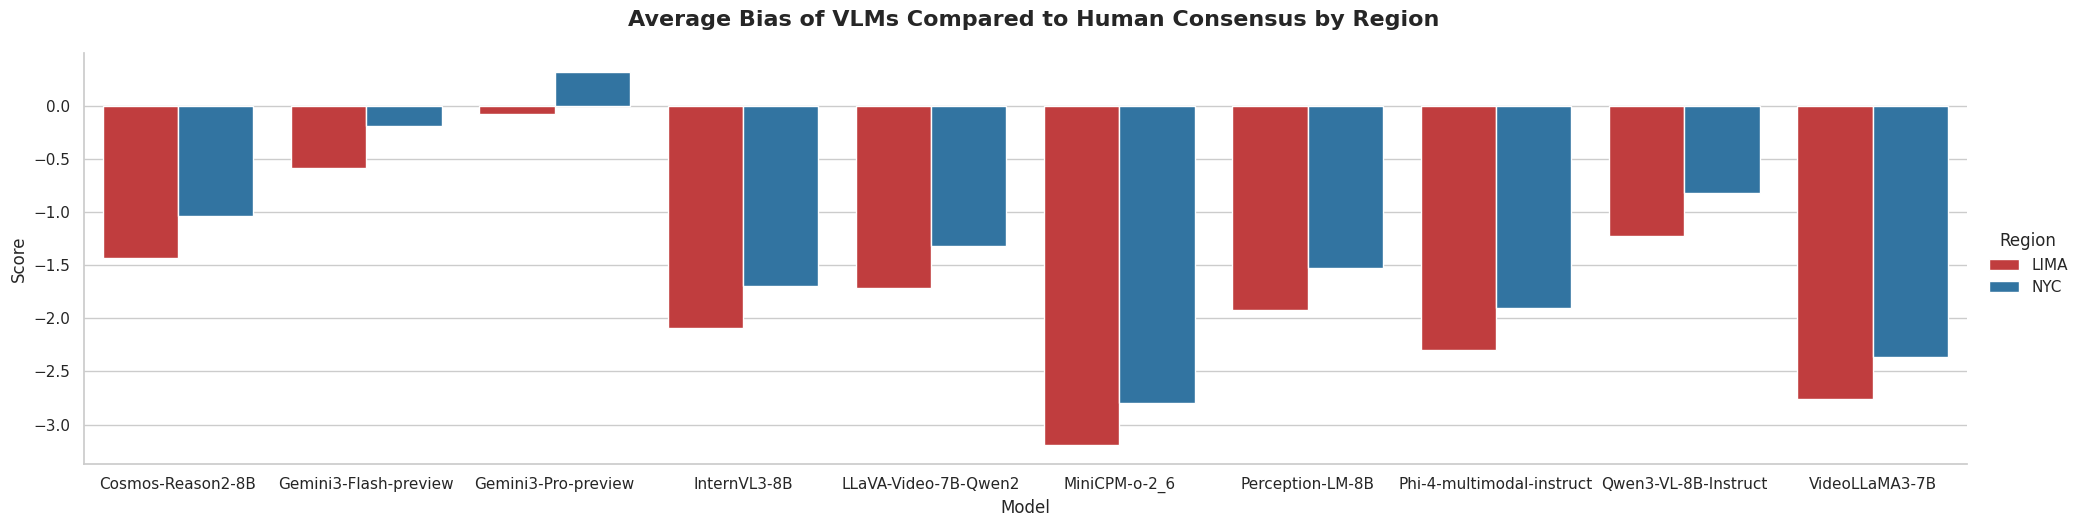

In [101]:
#make code to generete the summary table only by vlm and region with the mean bias for each question
summary_table = (
    r.groupby(["AGENT", "REGION"], as_index=False)
    .agg({"BIAS": "mean"}).reset_index(drop=True)
)

print(summary_table.head())
sns.color_palette("deep")

region_palette = {
    "NYC": "#1f77b4",
    "LIMA": "#d62728"
}

g = sns.catplot(
    data=summary_table,
    kind="bar",
    x="AGENT",
    y="BIAS",
    hue="REGION",           # un gráfico por región
    palette=region_palette,
    aspect=4,
    sharey=True
)

g.set_axis_labels("Model", "Score")
g.set_titles("{col_name}")
g._legend.set_title("Region")

g.figure.suptitle(
    "Average Bias of VLMs Compared to Human Consensus by Region",
    fontsize=16,
    fontweight='bold',
    y=1.05
)
plt.savefig("average_bias_by_region.png", dpi=150, bbox_inches='tight')
plt.show()